In [21]:
# Importo Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Ejercicio 1
 La función de costo marginal de una empresa está dada por $C'(q)=300+20q-12q^2$ y los costos fijos ascienden a $40000.
Determinar la función de costos totales y la de costo medio.
Graficar las funciones de costo medio y marginal en un mismo gráfico. Interpretar.


In [22]:
# Paso 1: Defino las variables simbólicas
q = sp.symbols('q', positive=True)
F = sp.symbols('F')

In [23]:
# Paso 2: Defino función a integrar
CMg = 300 + 20*q - 12*q**2
CMg

-12*q**2 + 20*q + 300

In [24]:
# Paso 3: Calculo integral
C = sp.integrate(CMg, q) + F
C

F - 4*q**3 + 10*q**2 + 300*q

In [25]:
# Valido que IMg sea la derivada de C
CMg == sp.diff(C, q)

True

In [ ]:
# Paso 4: Encuentro F sabiendo que C(0) = 40000
condicion = sp.Eq(C.subs(q, 0), 40000)
F_value = sp.solve(condicion, F)[0]
print('F_value:', F_value)

# Substituyo F_value en la función C
C = C.subs(F, F_value)
C

F_value: 40000


-4*q**3 + 10*q**2 + 300*q + 40000

In [28]:
# Paso 5: Hallo la función de Costo Medio
CMed = C / q
CMed = sp.simplify(CMed)
CMed

-4*q**2 + 10*q + 300 + 40000/q

In [31]:
# Paso 6: Grafico CMed y CMg para q entre 1 y 20

# 6.1 Creo dominio
q_vals = np.linspace(1, 20, 100)

In [32]:
# 6.2 Convierto funciones simbólicas a funciones numéricas
CMed_num = sp.lambdify(q, CMed, modules=['numpy']) # type: ignore
CMg_num = sp.lambdify(q, CMg, modules=['numpy']) # type: ignore

In [ ]:
# 6.3 Evalúo las funciones en la grilla de valores
CMed_vals = CMed_num(q_vals)
CMg_vals = CMg_num(q_vals)

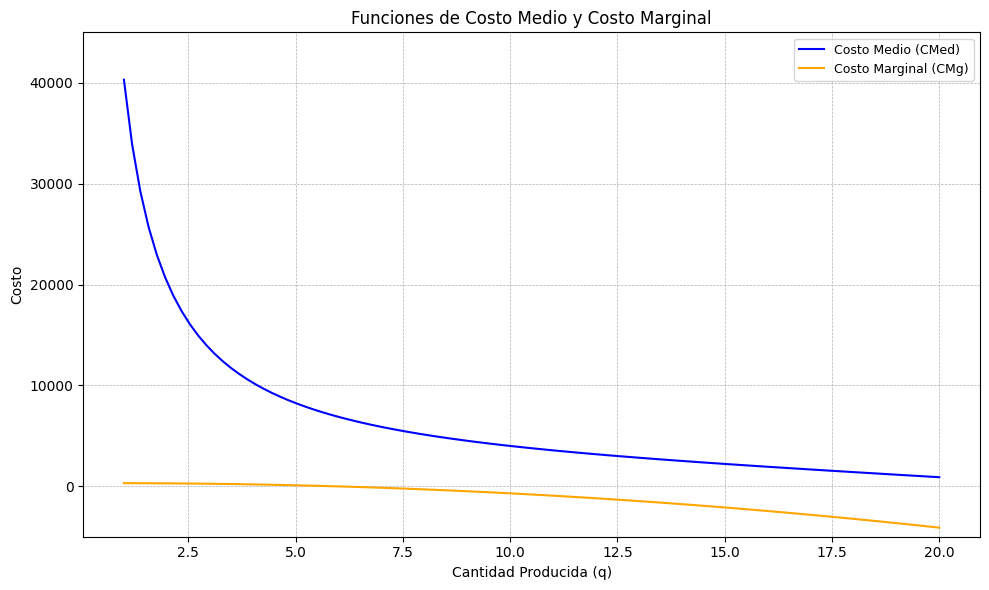

In [46]:
# 6.4 Visualizo las funciones CMed y CMg
fig, axs = plt.subplots(figsize=(10, 6))

# Grafico las funciones
axs.plot(q_vals, CMed_vals, label='Costo Medio (CMed)', color='blue')
axs.plot(q_vals, CMg_vals, label='Costo Marginal (CMg)', color='orange')

# Configuro Gráfico
axs.grid(True, which='both', linestyle='--', linewidth=0.5)
axs.set_title('Funciones de Costo Medio y Costo Marginal')
axs.set_xlabel('Cantidad Producida (q)')
axs.set_ylabel('Costo')
axs.set_ylim(-5000, 45000)
axs.legend(fontsize=9, loc='upper right')

fig.tight_layout()
plt.show()

# Ejercicio 2

**Problema:**

Supongamos que la función de ingreso marginal de una empresa está dada por:

$$ IMg(q) = 50 - 0.5 \cdot q $$

donde $q$ es la cantidad producida.

Además, sabemos que el costo marginal de la empresa es:

$$ CMg(q) = 10 + 0.3 \cdot q $$

y que el costo fijo es de $100.

**Resolver los siguientes puntos:**

1.  **Recuperar la función de ingreso total (I(q))**: Utiliza la integral indefinida para obtener la función de ingreso total a partir del ingreso marginal. Recuerda que el ingreso total es cero cuando la cantidad producida es cero ($I(0) = 0$).
2.  **Recuperar la función de costo total (C(q))**: Utiliza la integral indefinida para obtener la función de costo total a partir del costo marginal. Utiliza la información del costo fijo para determinar la constante de integración.
3.  **Calcular la función de beneficio total (B(q))**: Resta la función de costo total de la función de ingreso total para obtener la función de beneficio total.
4.  **Encontrar la cantidad óptima (q*)**: Determina la cantidad de producción que maximiza el beneficio igualando el ingreso marginal al costo marginal ($IMg(q) = CMg(q)$) y resolviendo para $q$.
5.  **Calcular el beneficio máximo (B(q*))**: Sustituye la cantidad óptima ($q^{*}$) en la función de beneficio total para encontrar el beneficio máximo.
6.  **Visualizar las funciones**: Grafica las funciones de ingreso total, costo total y beneficio total en el mismo gráfico para visualizar el punto de beneficio máximo.

# Ejercicio 3
Dadas las siguientes funciones de oferta y demanda:

$ qd=\sqrt{16-p}$

$ qs=p/2-1/2$  

Calcular EC y EP
Graficar ambas funciones en un mismo gráfico, donde el eje vertical debe ser el precio y el horizontal la cantidad.
Sombrear las áreas correspondientes a los excedentes encontrados indicando en el gráfico cuál es el excedente del consumidor y cuál el del productor


*   Recalcular los excedentes teniendo en cuenta que se implementa un impuesto de suma fija $t=3$ a los productores. Interpretar.
